# Starting with the simpliest case
##### author: M.Z. 
##### date: June 30th, 2026

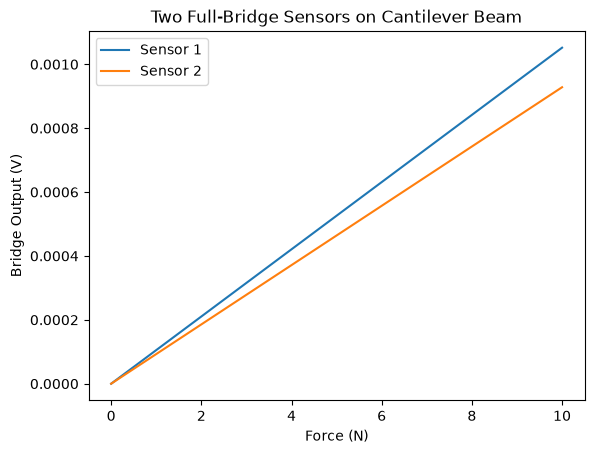

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Beam parameters
# ==============================
L = 0.02          # beam length (m)
E = 200e9        # Young's modulus (Pa) of SS
b = 0.008         # width (m)
t = 0.002        # thickness (m)

I = b * t**3 / 12   # moment of inertia of beam shape, actual design differs.
c = t / 2           # distance from neutral axis

# ==============================
# Sensor configuration
# ==============================
x1 = 0.003   # sensor 1 position (m), arbitrarily chosen to be closer to the fixed end, but can be adjusted as the current prototype is likely not the final design
x2 = 0.005   # sensor 2 position (m)

# Gauge parameters
GF = 2.0       # gauge factor
Vex = 3.3     # bridge excitation voltage (V)

# ==============================
# Full bridge model
# ==============================
def full_bridge_output(strain, GF, Vex):
    return Vex * GF * strain    # estimation, not directly modeling resistance changes in the bridge, but a simplified linear approximation

# ==============================
# Sweep force
# ==============================
forces = np.linspace(0, 10, 50)

V1s = []
V2s = []

for F in forces:
    # Strain at sensor positions (cantilever formula), but this is a tip-loaded (x = L) case
    strain1 = (F * (L - x1)) * c / (E * I)
    strain2 = (F * (L - x2)) * c / (E * I)

    # Full bridge outputs
    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    V1s.append(V1)
    V2s.append(V2)

# ==============================
# Plot results
# ==============================
plt.plot(forces, V1s, label="Sensor 1")
plt.plot(forces, V2s, label="Sensor 2")
plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Two Full-Bridge Sensors on Cantilever Beam")
plt.legend()
plt.show()

## now with a bit noise

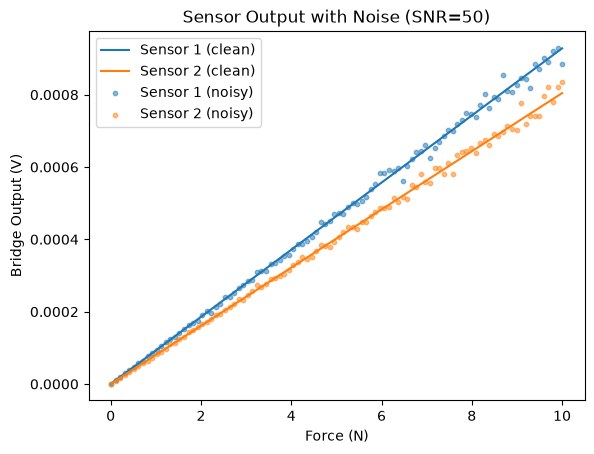

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, and Vex were already set up in the earlier setup cell.
# The bridge output helper is also already defined there.

# ==============================
# Force + contact location
# ==============================
forces = np.linspace(0.01, 10, 100)  # avoid 0 (for noise scaling)
x_force = 0.018  # where force is applied (near tip)

# ==============================
# Noise settings
# ==============================
SNR = 50  # signal-to-noise ratio

V1s = []
V2s = []
V1s_noisy = []
V2s_noisy = []

for F in forces:
    # strain based on arbitrary force location
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    # Add noise
    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1s.append(V1)
    V2s.append(V2)

    V1s_noisy.append(V1 + noise1)
    V2s_noisy.append(V2 + noise2)

# ==============================
# Plot
# ==============================
plt.plot(forces, V1s, label="Sensor 1 (clean)")
plt.plot(forces, V2s, label="Sensor 2 (clean)")

plt.scatter(forces, V1s_noisy, s=10, alpha=0.5, label="Sensor 1 (noisy)")
plt.scatter(forces, V2s_noisy, s=10, alpha=0.5, label="Sensor 2 (noisy)")

plt.xlabel("Force (N)")
plt.ylabel("Bridge Output (V)")
plt.title("Sensor Output with Noise (SNR=50)")
plt.legend()
plt.show()

## under this simpliest model, how different is the estimated force as compared with the input force

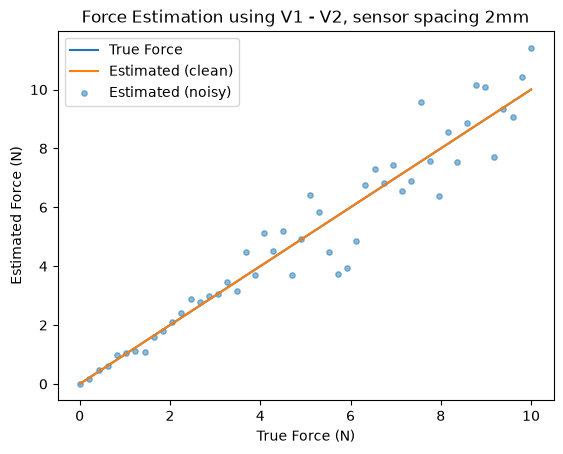

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, x2, GF, Vex, and full_bridge_output were already set up earlier.
# Only the force sweep and reconstruction logic are being evaluated here.

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.01, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 2mm")
plt.legend()
plt.show()

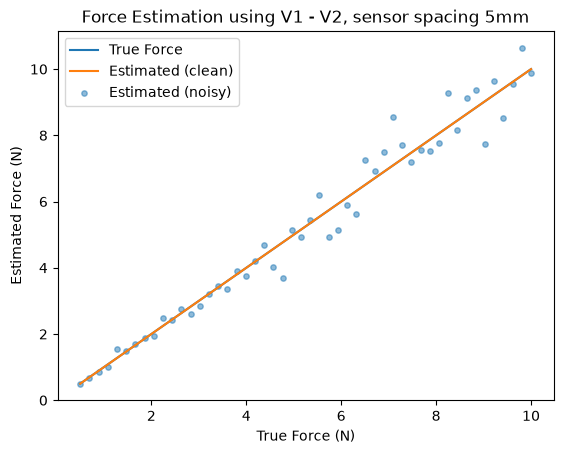

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing-specific update is being evaluated here.

# ==============================
# Sensor spacing update
# ==============================
x2 = 0.008  # updated second sensor position for the 5 mm spacing case

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 50)
x_force = 0.018

# ==============================
# Noise settings
# ==============================
SNR = 50

V1_clean = []
V2_clean = []
V1_noisy = []
V2_noisy = []

for F in forces:
    strain1 = (F * (x_force - x1)) * c / (E * I)
    strain2 = (F * (x_force - x2)) * c / (E * I)

    V1 = full_bridge_output(strain1, GF, Vex)
    V2 = full_bridge_output(strain2, GF, Vex)

    noise1 = V1 / SNR * np.random.randn()
    noise2 = V2 / SNR * np.random.randn()

    V1_clean.append(V1)
    V2_clean.append(V2)

    V1_noisy.append(V1 + noise1)
    V2_noisy.append(V2 + noise2)

# ==============================
# Force reconstruction: V1 - V2
# ==============================

# calibration factor (derived from model)
K = (Vex * GF * c / (E * I)) * (x2 - x1)

F_est_clean = []
F_est_noisy = []

for i in range(len(forces)):
    dV_clean = V1_clean[i] - V2_clean[i]
    dV_noisy = V1_noisy[i] - V2_noisy[i]

    F_est_clean.append(dV_clean / K)
    F_est_noisy.append(dV_noisy / K)

# ==============================
# Plot
# ==============================

plt.plot(forces, forces, label="True Force")
plt.plot(forces, F_est_clean, label="Estimated (clean)")
plt.scatter(forces, F_est_noisy, s=15, alpha=0.5, label="Estimated (noisy)")

plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Force Estimation using V1 - V2, sensor spacing 5mm")
plt.legend()
plt.show()

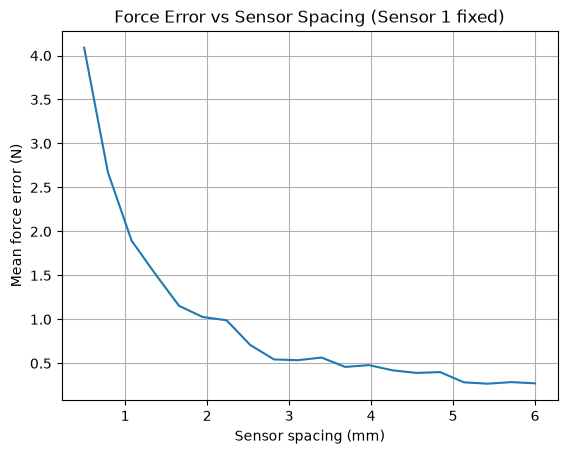

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Previously configured (unchanged)
# ==============================
# L, E, b, t, I, c, x1, GF, Vex, and full_bridge_output were already set up earlier.
# Only the spacing sweep logic is modified in this cell.

# ==============================
# Fixed sensor
# ==============================
# x1 = 0.003   # fixed sensor position, already configured earlier

# ==============================
# Force + location
# ==============================
forces = np.linspace(0.5, 10, 40)
x_force = 0.018

# ==============================
# Noise model
# ==============================
noise_floor = 5e-6
noise_prop = 1/50

# ==============================
# Sweep spacing
# ==============================
spacings = np.linspace(0.0005, 0.006, 20)

mean_errors = []

for d in spacings:
    x2 = x1 + d   # moving sensor

    F_errors = []

    # calibration (VERY important)
    K = (Vex * GF * c / (E * I)) * (x2 - x1)

    for F in forces:
        strain1 = (F * (x_force - x1)) * c / (E * I)
        strain2 = (F * (x_force - x2)) * c / (E * I)

        V1 = full_bridge_output(strain1, GF, Vex)
        V2 = full_bridge_output(strain2, GF, Vex)

        # noise (realistic)
        noise1 = noise_floor*np.random.randn() + V1*noise_prop*np.random.randn()
        noise2 = noise_floor*np.random.randn() + V2*noise_prop*np.random.randn()

        V1n = V1 + noise1
        V2n = V2 + noise2

        # force estimation
        F_est = (V1n - V2n) / K

        F_errors.append(abs(F_est - F))

    mean_errors.append(np.mean(F_errors))

# ==============================
# Plot
# ==============================
plt.plot(spacings*1000, mean_errors)
plt.xlabel("Sensor spacing (mm)")
plt.ylabel("Mean force error (N)")
plt.title("Force Error vs Sensor Spacing (Sensor 1 fixed)")
plt.grid()
plt.show()

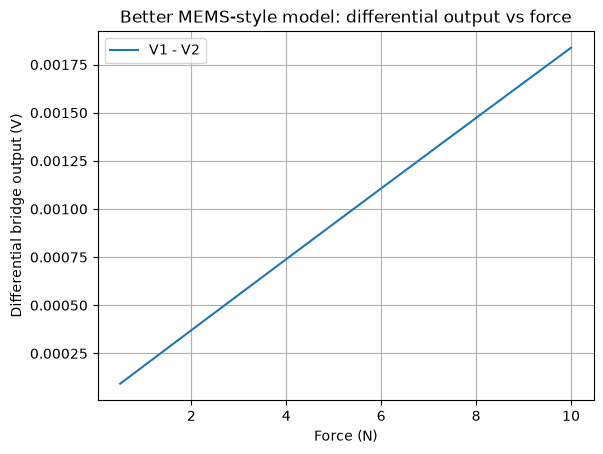

In [109]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Better MEMS-style model
# ==============================
L = 0.02
E = 200e9
b = 0.008
t = 0.002
nu = 0.3

I = b * t**3 / 12
c = t / 2

x1 = 0.003
x2 = 0.006
x_force = 0.018

R0 = 350
GF = 2.0
Vex = 3.3

forces = np.linspace(0.5, 10, 40)

# MEMS internal amplification and gradient parameters
G = 20
h_mem = 50e-6


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def mems_bridge_output(eps, G=G, h_mem=h_mem):
    """Single-surface MEMS bridge with internal strain gradient.

    A realistic MEMS strain-gauge bridge should not place all four gauges with the
    same signed strain sensitivity. In a real die, neighboring gauges are usually
    oriented so that one arm sees a positive strain change while the opposite arm
    sees a negative strain change. That is what makes the Wheatstone bridge output
    respond to bending instead of cancelling out.
    """
    # Mechanical strain is amplified by the MEMS flexure before it reaches the
    # piezoresistive elements embedded in the membrane.
    eps0 = G * eps

    # Internal gauge-height pattern for a physically realistic single-surface bridge.
    # The signs are intentionally asymmetric so adjacent arms see opposite-signed
    # strain contributions. If the pattern were perfectly symmetric, the bridge
    # would be locally balanced and the differential output would collapse to zero.
    y = np.array([-0.5, 0.5, 0.5, -0.5]) * h_mem
    kappa = eps0 / max(h_mem, 1e-12)
    eps_local = eps0 + kappa * y

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    # Differential bridge output: a real MEMS sensor relies on the two halves of
    # the bridge seeing opposite resistance changes to generate a nonzero output.
    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


Vdiff = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff.append(V1 - V2)

plt.plot(forces, Vdiff, label="V1 - V2")
plt.xlabel("Force (N)")
plt.ylabel("Differential bridge output (V)")
plt.title("Better MEMS-style model: differential output vs force")
plt.grid()
plt.legend()
plt.show()

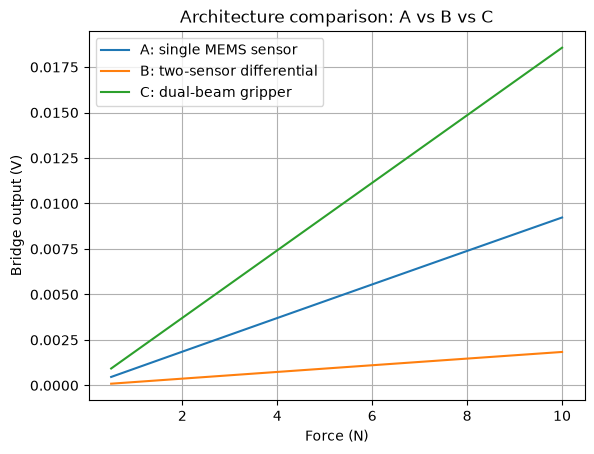

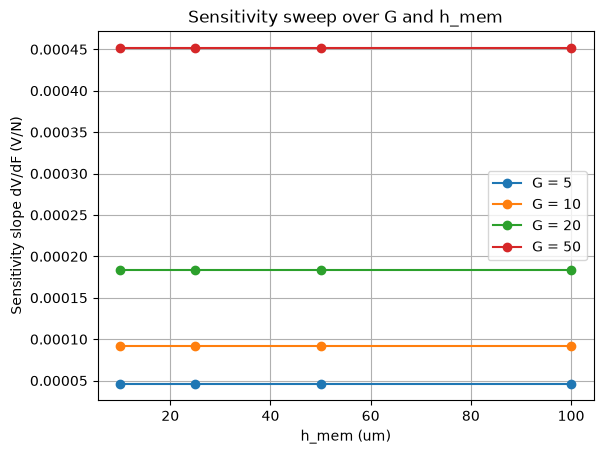

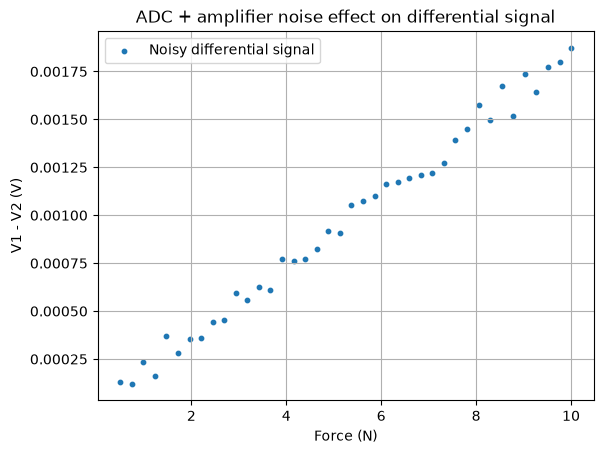

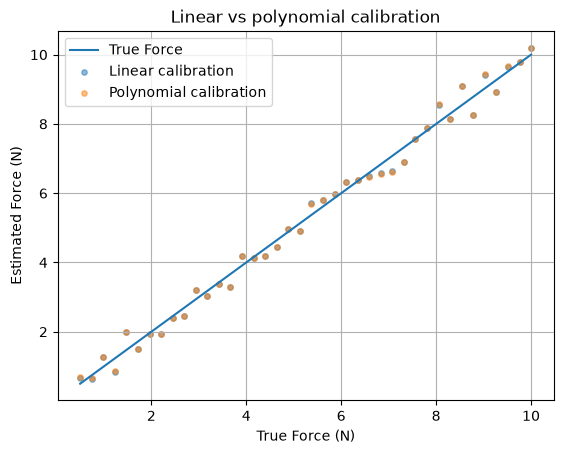

: 

In [ ]:
# ==============================
# A. Single MEMS sensor comparison (A vs B vs C)
# ==============================

L = 0.02
E = 200e9
b = 0.008
t = 0.002
I = b * t**3 / 12
c = t / 2

x_force = 0.018
forces = np.linspace(0.5, 10, 40)

x1 = 0.003
x2 = 0.006
x_A = x1
x_B = x2
x_C = 0.009

R0 = 350
GF = 2.0
Vex = 3.3
G = 20
h_mem = 50e-6


def beam_strain(F, x):
    return (F * (x_force - x)) * c / (E * I)


def mems_bridge_output(eps, G=G, h_mem=h_mem):
    eps0 = G * eps
    y = np.array([-0.5, 0.5, 0.5, -0.5]) * h_mem
    kappa = eps0 / max(h_mem, 1e-12)
    eps_local = eps0 + kappa * y

    R1 = R0 * (1 + GF * eps_local[0])
    R2 = R0 * (1 + GF * eps_local[1])
    R3 = R0 * (1 + GF * eps_local[2])
    R4 = R0 * (1 + GF * eps_local[3])

    return Vex * ((R2 / (R1 + R2)) - (R4 / (R3 + R4)))


def architecture_response(x):
    return np.array([mems_bridge_output(beam_strain(F, x)) for F in forces])

A_single = architecture_response(x_A)
B_diff = np.array([mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(beam_strain(F, x2)) for F in forces])
C_dual = np.array([
    mems_bridge_output(beam_strain(F, x1)) - mems_bridge_output(-beam_strain(F, x1))
    for F in forces
])

plt.figure()
plt.plot(forces, A_single, label="A: single MEMS sensor")
plt.plot(forces, B_diff, label="B: two-sensor differential")
plt.plot(forces, C_dual, label="C: dual-beam gripper")
plt.xlabel("Force (N)")
plt.ylabel("Bridge output (V)")
plt.title("Architecture comparison: A vs B vs C")
plt.legend()
plt.grid()
plt.show()

# ==============================
# B. Sweep G and h_mem for sensitivity analysis
# ==============================
G_values = np.array([5, 10, 20, 50])
h_mem_values = np.array([10e-6, 25e-6, 50e-6, 100e-6])

sensitivity_map = []
for G in G_values:
    row = []
    for h_mem in h_mem_values:
        Vdiff_list = []
        for F in forces:
            eps1 = beam_strain(F, x1)
            eps2 = beam_strain(F, x2)
            V1 = mems_bridge_output(eps1, G=G, h_mem=h_mem)
            V2 = mems_bridge_output(eps2, G=G, h_mem=h_mem)
            Vdiff_list.append(V1 - V2)
        slope, _ = np.polyfit(forces, Vdiff_list, 1)
        row.append(slope)
    sensitivity_map.append(row)

sensitivity_map = np.array(sensitivity_map)

plt.figure()
for i, G in enumerate(G_values):
    plt.plot(h_mem_values * 1e6, sensitivity_map[i], marker='o', label=f'G = {G}')

plt.xlabel("h_mem (um)")
plt.ylabel("Sensitivity slope dV/dF (V/N)")
plt.title("Sensitivity sweep over G and h_mem")
plt.legend()
plt.grid()
plt.show()

# ==============================
# C. Add ADC quantization and amplifier noise
# ==============================
adc_bits = 16
adc_fullscale = 3.3
adc_lsb = adc_fullscale / (2**adc_bits)
amp_noise_rms = 5e-6
noise_prop = 1/50

Vdiff_clean = []
Vdiff_noisy = []
for F in forces:
    eps1 = beam_strain(F, x1)
    eps2 = beam_strain(F, x2)
    V1 = mems_bridge_output(eps1)
    V2 = mems_bridge_output(eps2)
    Vdiff = V1 - V2

    amp = amp_noise_rms * np.random.randn()
    quant = adc_lsb * np.random.normal(0, 1)
    prop = Vdiff * noise_prop * np.random.randn()

    Vdiff_clean.append(Vdiff)
    Vdiff_noisy.append(Vdiff + amp + quant + prop)

plt.figure()
plt.scatter(forces, Vdiff_noisy, s=10, label="Noisy differential signal")
plt.xlabel("Force (N)")
plt.ylabel("V1 - V2 (V)")
plt.title("ADC + amplifier noise effect on differential signal")
plt.grid()
plt.legend()
plt.show()

# ==============================
# D. Compare linear vs polynomial calibration
# ==============================
Vdiff_clean = np.array(Vdiff_clean)
Vdiff_noisy = np.array(Vdiff_noisy)

linear_cal = np.polyfit(Vdiff_clean, forces, 1)
poly_cal = np.polyfit(Vdiff_clean, forces, 3)

F_lin = np.polyval(linear_cal, Vdiff_noisy)
F_poly = np.polyval(poly_cal, Vdiff_noisy)

plt.figure()
plt.plot(forces, forces, label="True Force")
plt.scatter(forces, F_lin, s=15, alpha=0.5, label="Linear calibration")
plt.scatter(forces, F_poly, s=15, alpha=0.5, label="Polynomial calibration")
plt.xlabel("True Force (N)")
plt.ylabel("Estimated Force (N)")
plt.title("Linear vs polynomial calibration")
plt.legend()
plt.grid()
plt.show()